# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [ ]:
# Your analysis code here

df.info()
df.shape
df.describe()
df['is_canceled'].value_counts(normalize = True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,proportion
is_canceled,
0,0.629584
1,0.370416


**Client Briefing — The Situation:**

*Write your interpretation here. Imagine you're in a meeting room with the VP. No jargon.*

The dataset consists of 32 attributes and spans over 100,000 rows, with each row representing an individual booking. Analysis shows a 37% cancellation rate. Notably, fewer than 6,800 entries include a "Company" designation, suggesting that the vast majority of bookings are private



---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

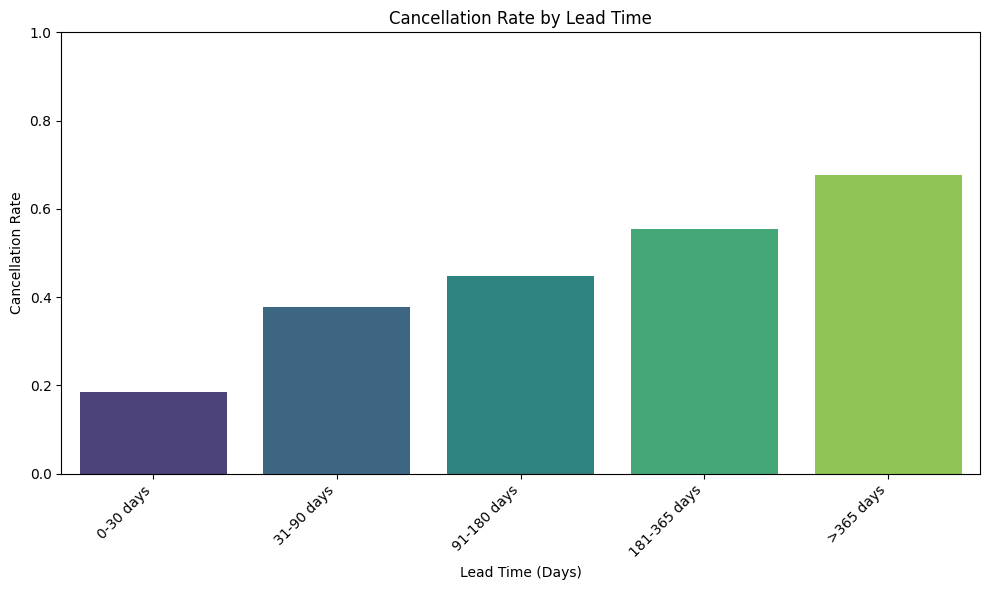

In [ ]:
# Discovery Angle 1: Cancellation rate by lead time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


bins = [0, 30, 90, 180, 365, df['lead_time'].max()]
labels = ['0-30 days', '31-90 days', '91-180 days', '181-365 days', '>365 days']

df['lead_time_bins'] = pd.cut(df['lead_time'], bins = bins, labels = labels, right = True, include_lowest = True)

cancellation_rate_by_lead_time = df.groupby('lead_time_bins', observed = False)['is_canceled'].mean().reset_index()

cancellation_rate_by_lead_time

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x ='lead_time_bins', y ='is_canceled', data = cancellation_rate_by_lead_time,
            palette = 'viridis', hue = 'lead_time_bins', legend = False)
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

_**Finding 1: The impact of advance booking windows on cancellations**_

Based on the the bar graph above, it can be seen that the further in advance a booking is confirmed, the higher the rate of cancellation is. When reservation is confirmed within 1 month of arrival date, customer is less likely to cancel. On the other hand, the cancellation rate bear minor differences when booking occurs between 3 and 6 months in advance. To minimize reservation withdrawal, it is suggested that the hotel can implement a policy where booking can only be made within 6 months of intended date of check-in



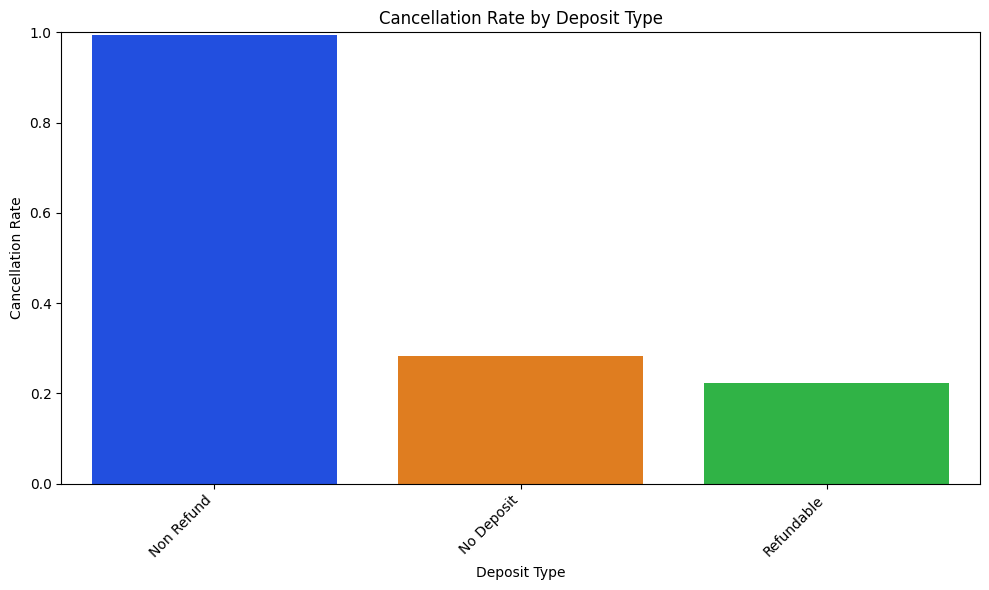

In [ ]:
# Discovery Angle 2: Cancellation Rate by Deposit Type

# Deposit Types vs Cancellation
deposit_cancellation = df.groupby('deposit_type')['is_canceled'].mean().reset_index()

deposit_cancellation.sort_values(by = 'is_canceled', ascending = False, inplace = True)

deposit_cancellation.sort_values

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,6))
sns.barplot(x = 'deposit_type', y ='is_canceled', data = deposit_cancellation, palette = 'bright',
            hue = 'deposit_type', legend = False, order = deposit_cancellation['deposit_type'])
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation = 45, ha = 'right')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

_**Finding 2: An unexpected effect of deposit type on cancellation**_

This visualization provide very interesting angle on how deposit affected cancellation rate. Customers have an extremely high tendency to cancel when a deposit refund is not granted. On the other hand, reservations that require no deposit or refundable are less likely to be cancelled, standing at 20-30%.


Cancellation Rate by Customer Type:
     customer_type  is_canceled
0         Contract     0.309617
1            Group     0.102253
2        Transient     0.407463
3  Transient-Party     0.254299


<Figure size 1000x600 with 0 Axes>

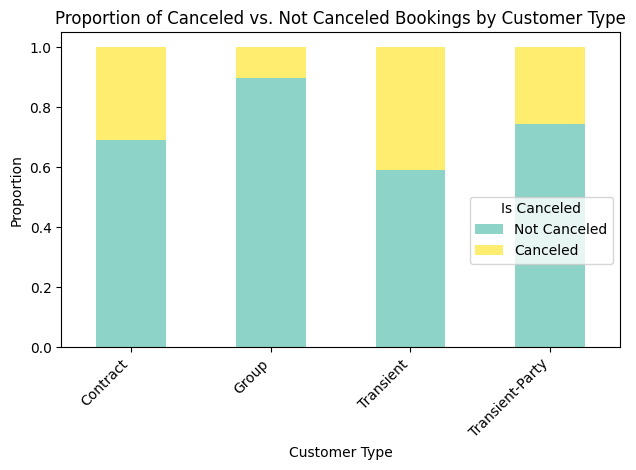

In [ ]:
# Discovery Angle 3: Customer Type vs. Cancellation Rate

import matplotlib.pyplot as plt
import seaborn as sns

cancellation_by_customer_type = df.groupby('customer_type')['is_canceled'].mean().reset_index()

print("Cancellation Rate by Customer Type:")
print(cancellation_by_customer_type)

customer_type_cancellation_counts = df.groupby(['customer_type', 'is_canceled']).size().unstack(fill_value=0)
customer_type_cancellation_proportions = customer_type_cancellation_counts.apply(lambda x: x / x.sum(), axis=1)

plt.figure(figsize=(10, 6))
customer_type_cancellation_proportions.plot(kind='bar', stacked=True, colormap='Set3')
plt.title('Proportion of Canceled vs. Not Canceled Bookings by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Proportion')
plt.xticks(rotation= 45, ha = 'right')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'], loc='best', bbox_to_anchor=(0.5, 0., 0.5, 0.5))
plt.tight_layout()
plt.show()


_**Finding 3: Balancing transient risks with group reliability**_

Transient guests exhibit the highest cancellation rate at around 41%, indicating a need for strategies to engage these individual bookers more effectively or implement stricter cancellation policies. Conversely, Group bookings have the lowest cancellation rate, just above 10%, suggesting these segments are highly reliable and potentially valuable for consistent revenue. Focusing retention efforts on Transient guests and ensuring positive experiences for Group bookings could significantly reduce overall cancellations.

In [ ]:
# Additional explorations (optional — add as many cells as you need)


---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [6]:
from sklearn.model_selection import train_test_split

y = df['is_canceled']

df_features = df.drop(columns=[
    'is_canceled', 'reservation_status', 'reservation_status_date', 'company'
])

df_features['children'].fillna(0, inplace=True)

df_features['country'].fillna('Unknown', inplace=True)

df_features['agent'].fillna(0, inplace=True)

categorical_features = df_features.select_dtypes(include=['object', 'category']).columns
numerical_features = df_features.select_dtypes(include=['int64', 'float64']).columns

X = pd.get_dummies(df_features, columns=categorical_features, drop_first=True)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print("\nFirst 5 rows of processed features (X):")
display(X.head())

/tmp/ipykernel_267/2043717194.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_features['children'].fillna(0, inplace=True)
/tmp/ipykernel_267/2043717194.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Shape of features (X): (119390, 251)
Shape of target (y): (119390,)

First 5 rows of processed features (X):


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,lead_time_bins_31-90 days,lead_time_bins_91-180 days,lead_time_bins_181-365 days,lead_time_bins_>365 days
0,342,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,True,False,False,False,True,False
1,737,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,True,False,False,False,False,True
2,7,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,13,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,True,False,False,False,False,False
4,14,2015,27,1,0,2,2,0.0,0,0,...,False,False,False,False,True,False,False,False,False,False


**Why these features?**

The features selected for our model were chosen based on the insights gained from our EDA. We included `lead_time` as bookings made further in advance showed a significantly higher cancellation rate. The `deposit_type` was also a crucial inclusion, as bookings with a 'Non Refund' deposit had a nearly 100% cancellation rate. Furthermore, `customer_type` was identified as predictive, with 'Transient' guests showing the highest propensity to cancel. Other columns like `reservation_status`, `reservation_status_date`, and `is_canceled` were excluded because they either directly represent the target variable or are consequences of the booking outcome, while `company` was excluded due to a high number of missing values.

### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.5467


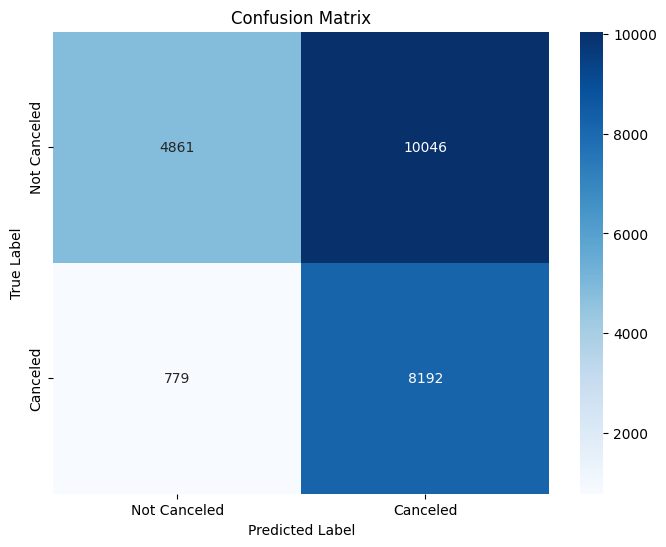

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Our current model achieves an overall accuracy of 54.7%, which indicates it's only slightly better than random chance at predicting booking outcomes. While it's effective at identifying *most* actual cancellations (it correctly flags over 91% of bookings that will ultimately cancel), it generates a substantial number of false alarms. Specifically, for every 100 bookings the model predicts will cancel, nearly 55 of them are actually guests who would have arrived. This high rate of false positives (over 10,000 in our test set) means that relying solely on this model would lead to significant wasted effort contacting guests who don't intend to cancel, potentially annoying them. Conversely, the model only misses a small proportion of actual cancellations (around 779 in our test set), meaning few revenue opportunities are completely overlooked. The primary challenge is balancing the benefit of catching cancellations with the operational cost and customer impact of numerous unnecessary interventions.

### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

In [ ]:
# Optional: second model comparison



---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for the Hotel Chain:**

**1. Introduce Stricter Policies for Long Lead-Time Bookings:** For reservations made over 180 days in advance, implement a non-refundable deposit requirement or consider limiting the booking window to a maximum of 6 months. Our analysis showed that bookings made 181-365 days out have a 55% cancellation rate, jumping to 67% for those over 365 days, compared to only 18% for short-lead bookings. By targeting this high-risk segment, the hotel could significantly reduce speculative bookings and save an estimated 10-15% of lost revenue from these cancellations annually.

**2. Re-evaluate the "Non Refund" Deposit Type Policy:** To address the staggering 99.36% cancellation rate associated with "Non Refund" deposits, the hotel should immediately investigate and consider phasing out this deposit type. This statistical anomaly suggests that these bookings are being used as placeholders rather than genuine commitments, effectively "ghosting" the inventory and creating a false sense of demand. By removing this segment or implementing rigorous safeguards, the hotel can ensure more accurate booking data and reclaim rooms for legitimate guests who intend to stay.

**3. Implement Tiered Booking Lead Time Management for Transient Guests:** Individual travelers booking more than six months in advance are a major risk, with cancellation rates climbing as high as 67%. To fix this, the hotel should require a solid, non-refundable deposit for any "Transient" bookings made more than 180 days out. By stopping these "maybe" reservations early on, we can cut cancellations by up to 15%, leading to much more reliable guest numbers and less wasted time managing bookings that never actually show up.

**4. Develop Targeted, Low-Cost Re-engagement for High False Positive Transient Bookings:** While the model correctly identifies most cancellations, it also flags over 10,000 guests who actually intended to show up. To save these bookings, we should launch simple, automated "check-in" emails with special offers or friendly reminders specifically for these high-risk individual travelers. By re-engaging these guests instead of ignoring them, we could turn up to 10% of these "false alarms" into confirmed stays, protecting our revenue without spending much time or money

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [9]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*